# Проект. Исследование стартапов


## Введение

### Цель и задачи проекта

**Цель:** Выявить закономерности финансирования стартапов на исторических данных для оценки эффективности инвестиционных стратегий и обоснования решений по покупке.

**Задачи:**
1. Очистить и подготовить данные к анализу.
2. Сегментировать стартапы по срокам, объемам и типам финансирования. 
3. Оценить динамику инвестиций во времени и по сегментам рынка. 
4. Проанализировать возвратность по разным типам финансирования. 
5. Сделать выводы и предложить обоснованные рекомендации для инвестиций.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

*Загрузите необходимые для работы библиотеки.*

In [1]:
# Установка
!pip install missingno -q

In [2]:
# Импортируем все необходимые библиотеки
import pandas as pd 
import numpy as np
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

*Загрузите все данные по проекту.*

In [3]:
# Данные будут сохранены в две переменные df_investments и df_returns
df_investments = pd.read_csv('https://code.s3.yandex.net/datasets/cb_investments.zip', sep = ';', low_memory = False)
df_returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

*Выведите информацию, которая необходима для принятия решений о предобработке.*

In [4]:
# Выведем информацию и первые пять строк по df_investments
display(df_investments.info())
display(df_investments.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

None

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Выведем информацию и первые пять строк по df_returns
display(df_returns.info())
display(df_returns.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


None

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


*Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.*

**Выводы по общей информации:**

Датасет `df_investments` содержит 54 294 записи и 40 столбцов. Данные соответствуют описанию. Основные первичные наблюдения:
- Много пропусков в ключевых полях `name`, `category_list`, `market`, `state_code`, `city`, `founded_at`.
- Поле `funding_total_usd` представлено как строка с нестандартным форматом чисел (например, `9,00,00,000`), требует очистки и конвертации в `float`.
- Также необходимо предобразовать формат колонок с датами.

Датасет `df_returns` содержит 15 записей и 14 столбцов. Данные соответствуют описанию. Датасет не имеет пропусков. Все столбцы имеют корректный тип данных.

### 1.2. Предобработка данных

*Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.*

In [6]:
# Приводим названия столбцов к единому "змеиному" стилю, убирая лишние пробелы, делая нижний регистр и заменяя пробелы на _
df_investments.columns = (df_investments.columns.str.strip().str.lower().str.replace(' ', '_'))
display(df_investments.columns)
df_returns.columns = (df_returns.columns.str.strip().str.lower().str.replace(' ', '_'))
display(df_returns.columns)

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

*Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.*

In [7]:
# Приводим данные в funding_total_usd к корректному типу
# Убираем лишние пробелы и разрядность (,), заменяем прочерки на пустые значения
df_investments['funding_total_usd'] = (
    df_investments['funding_total_usd'].str.strip().str.replace(',', '', regex = False).replace('-', np.nan, regex = False)
)
# Приводим данные к числовому формату 
df_investments['funding_total_usd'] = pd.to_numeric(df_investments['funding_total_usd'], errors = 'coerce')
df_investments['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

*Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.*

In [8]:
# Поменяем тип данных в столбцах 'founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at'
column_date = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']
for col in column_date:
    df_investments[col] = pd.to_datetime(df_investments[col], errors = 'coerce')
# Посмотрим на результат замены типа данных
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

*В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.*

In [9]:
# Делаем 'year' индексом 
df_returns = df_returns.set_index('year')
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


*Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.*

In [10]:
# Поменяем пропущенные данные в текстовых полях на заглушку 'n/d'
column_text = ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']
for col in column_text:
    df_investments[col] = df_investments[col].fillna('n/d')
df_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,n/d,n/d,2000000.0,operating,n/d,n/d,n/d,n/d,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


*Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.*

In [11]:
# Выявим количество явных дубликатов
df_investments.duplicated().sum()

4855

In [12]:
# Удаляем явные дубликаты из данных
df_investments = df_investments.drop_duplicates()

In [13]:
# Удаляем данные, в которых есть пропуски в поле 'funding_total_usd'
df_investments = df_investments.dropna(subset = ['funding_total_usd'])

*Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.*

*Оцените размер оставшихся пропусков в столбце.*

In [14]:
# Определяем серидину интервала между датами 'first_funding_at' и 'last_funding_at'
mean_date = (df_investments['first_funding_at'] + (df_investments['last_funding_at'] - df_investments['first_funding_at']) / 2)
# Заполняем пропуски серединой интервала
df_investments['mid_funding_at'] = df_investments['mid_funding_at'].fillna(mean_date)
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40907 non-null  object        
 1   homepage_url          40907 non-null  object        
 2   category_list         40907 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                40907 non-null  object        
 6   country_code          40907 non-null  object        
 7   state_code            40907 non-null  object        
 8   region                40907 non-null  object        
 9   city                  40907 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month   

In [15]:
# Посмотрим долю пропусков в каждом из столбцов
df_investments.isna().mean()

name                    0.000000
homepage_url            0.000000
category_list           0.000000
market                  0.000000
funding_total_usd       0.000000
status                  0.000000
country_code            0.000000
state_code              0.000000
region                  0.000000
city                    0.000000
funding_rounds          0.000000
participants            0.331875
founded_at              0.212849
founded_month           0.214438
founded_quarter         0.214438
founded_year            0.212824
first_funding_at        0.000049
mid_funding_at          0.000024
last_funding_at         0.000000
seed                    0.000000
venture                 0.000000
equity_crowdfunding     0.000000
undisclosed             0.000000
convertible_note        0.000000
debt_financing          0.000000
angel                   0.000000
grant                   0.000000
private_equity          0.000000
post_ipo_equity         0.000000
post_ipo_debt           0.000000
secondary_

<Figure size 936x432 with 0 Axes>

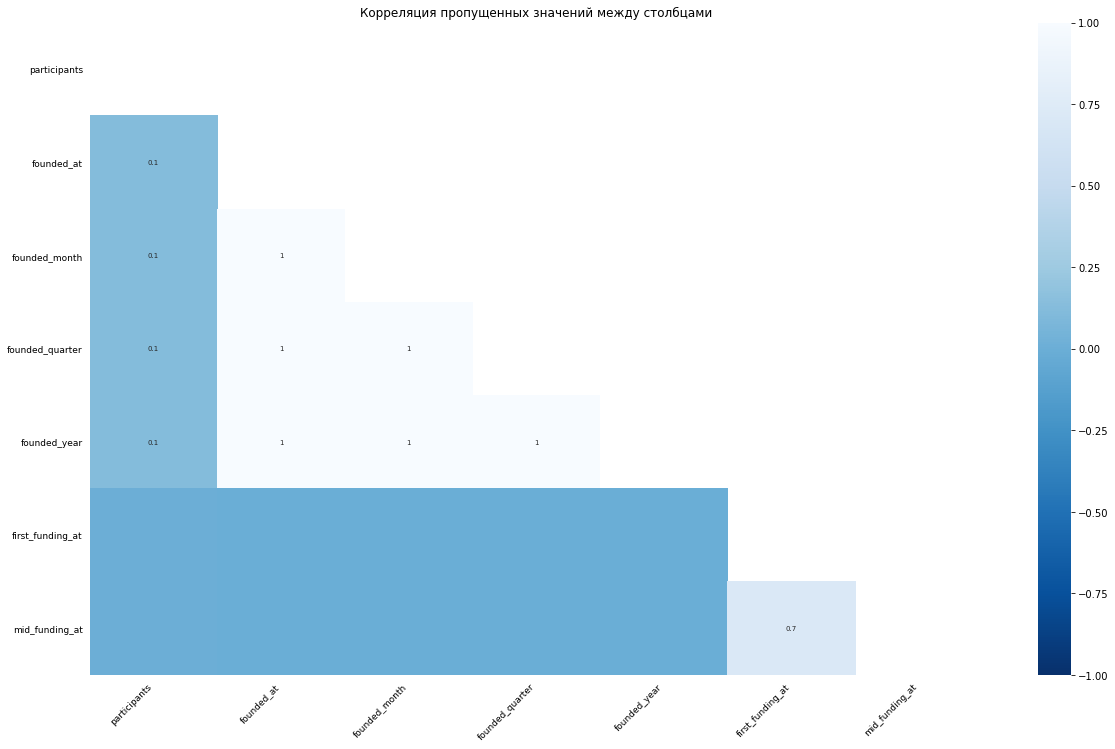

In [16]:
# Тепловая карта корреляции пропусков 
plt.figure(figsize = (13, 6))
msno.heatmap(df_investments, 
             cmap = 'Blues_r', 
             fontsize = 9)
plt.title('Корреляция пропущенных значений между столбцами')
plt.show()

*Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?*

**Что сделано:**
- Приведены названия столбцов к единому "змеиному" стилю.
- Исправлен формат поля `funding_total_usd` и преобразован в числовой тип.
- Поля с датами преобразованы в тип `datetime64[ns]`.
- Удалено *4 855 явных дубликатов* и строки с пропусками в `funding_total_usd`.
- Заполнены пропуски в поле `mid_funding_at` средним интервалом между `first_funding_at` и `last_funding_at`.
- Пропуски в текстовых полях заполнены заглушкой `'n/d'`.

**Размер выборки:**
- Исходный размер: *54 294* строк.
- После удаления явных дубликатов и строк с пропусками в `funding_total_usd`: *40 907* строк.
- Отброшено: *13 387* строк (~25%).

В выборке были оставлены **компании с известной суммой финансирования**. Сумма финансирования является ключевым показателем для исследования. С точки зрения инвестиционного анализа строки без известной суммы финансирования неинформативны. 

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

*Разделите все компании на три группы:*

* *Единичное финансирование — был всего один раунд финансирования.*

* *Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.*

* *Срок финансирования более года.*

*Визуализируйте соотношение этих групп, создав два графика:*

* *По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.*
* *По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.*

In [17]:
# Создаем поле 'funding_durarion_days', в котором вычисляется разница между 'last_funding_at' и 'first_funding_at' в днях
df_investments['funding_durarion_days'] = (df_investments['last_funding_at'] - df_investments['first_funding_at']).dt.days
# Создаем функцию, которая будет распределять компании на группы
def funding_group(row):
    # Единичное финансирование - был всего один раунд финансирования
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_rounds'] > 1:
        if row['funding_durarion_days'] <= 365:
            return 'Срок финансирования до года'
        elif row['funding_durarion_days'] > 365:
            return 'Срок финансирования более года'
    else:
        return np.nan
# Создадим поле 'funding_group' и применим созданную функцию к нему 
df_investments['funding_group'] = df_investments.apply(funding_group, axis = 1)

In [18]:
# Произведем агрегацию по количеству и суммарному объему привлеченных инвестиций
group_summary = (
    df_investments
    .groupby('funding_group')
    .agg(
        count = ('funding_group', 'count'),
        total_funding = ('funding_total_usd', 'sum')
    )
)
# Для анализа добавим доли 
group_summary['company_share'] = group_summary['count'] / group_summary['count'].sum()
group_summary['funds_share'] = group_summary['total_funding'] / group_summary['total_funding'].sum()
group_summary

,count,total_funding,company_share,funds_share
funding_group,,,,
Единичное финансирование,24113,1.993044e+11,0.589488,0.306199
Срок финансирования более года,12291,4.027090e+11,0.300477,0.618696
Срок финансирования до года,4501,4.888598e+10,0.110035,0.075105


In [19]:
# Создадим единую палитру для графиков 
colors = {
    'Единичное финансирование': '#FF6F61',
    'Срок финансирования до года': '#6ECEDA',
    'Срок финансирования более года': '#4A90E2'
}
group_order = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']
bar_colors = [colors[g] for g in group_order]

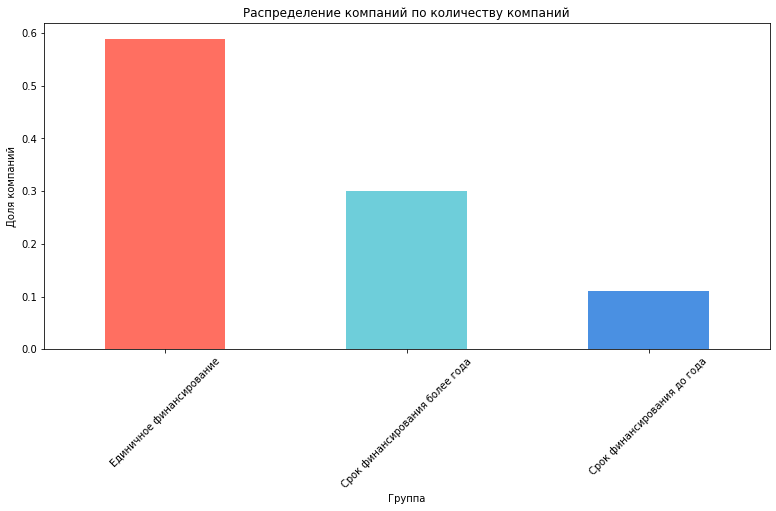

In [20]:
# График 1: По количеству компаний
plt.figure(figsize = (13, 6))
group_summary['company_share'].plot(
    kind = 'bar',
    color = bar_colors,
    legend = False,
    rot = 45
)
plt.title('Распределение компаний по количеству компаний')
plt.xlabel('Группа')
plt.ylabel('Доля компаний')
plt.show()

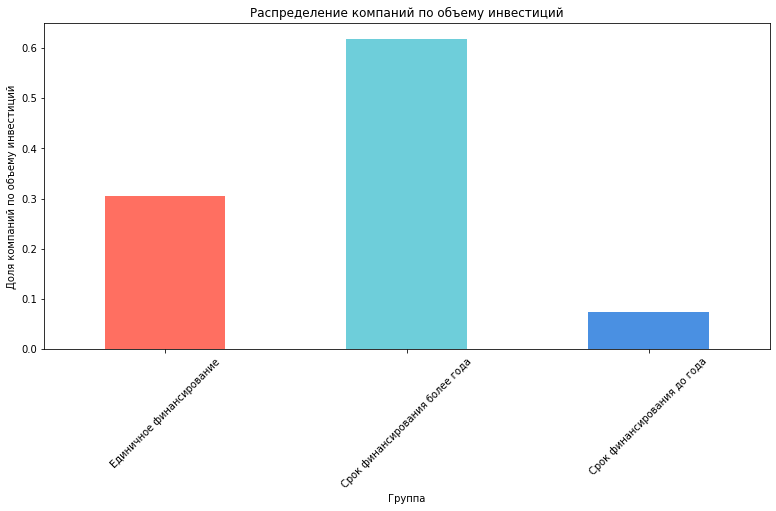

In [21]:
# График 2: По объему инвестиций
plt.figure(figsize = (13, 6))
group_summary['funds_share'].plot(
    kind = 'bar',
    color = bar_colors,
    legend = False,
    rot = 45
)
plt.title('Распределение компаний по объему инвестиций')
plt.xlabel('Группа')
plt.ylabel('Доля компаний по объему инвестиций')
plt.show()

**Выводы по группам по срокам финансирования:**
- *Подавляющее большинство компаний (58,9%) получают финансирование единожды*. При этом на низ приходится лишь 30,6% от общего объема инвестиций. Это может говорить о том, что такие компании - это, в основном, небольшие проекты, имеющие ограниченный рост или ранний выход.
- *Компании с длительным финансированием (больше года) - меньшинство по количеству (30.0%), но лидеры по объему привлеченных средств (61,9%)*. Являются ядром венчерного портфеля: масштабируемые стартапы, проходящие несколько раундов. 
- *Краткосрочные раунды (менее года) - самая малочисленная группа (11,0%) и наименее капиталоемкая (7,5%)*. Возможно, в эту группу входят проекты с быстрой монетизацией. 

### 2.2 Выделение средних и нишевых сегментов рынка

*Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.*

*Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.*

In [22]:
# Приводим все значения в 'market' к одному стилю
df_investments['market'] = df_investments['market'].str.strip()
# Рассчитываем частоту каждого сегмента 
market_counts = df_investments['market'].value_counts()
# Создаем функцию для классификации сегментов
def class_market(count):
    if count > 120:
        return 'Массовые'
    elif 35 < count <= 120:
        return 'Средние'
    else:
        return 'Нишевые'
# Произведем классификацию
market_class = market_counts.to_frame(name = 'count')
market_class['category'] = market_class['count'].apply(class_market)
# Рассчитаем количество сегментов каждой категории 
segment_stats = market_class['category'].value_counts()
print('Количество уникальных сегментов: ', df_investments['market'].nunique())
print('Количество сегментов:')
print(segment_stats)

Количество уникальных сегментов:  395
Количество сегментов:
Нишевые     289
Средние      57
Массовые     49
Name: category, dtype: int64


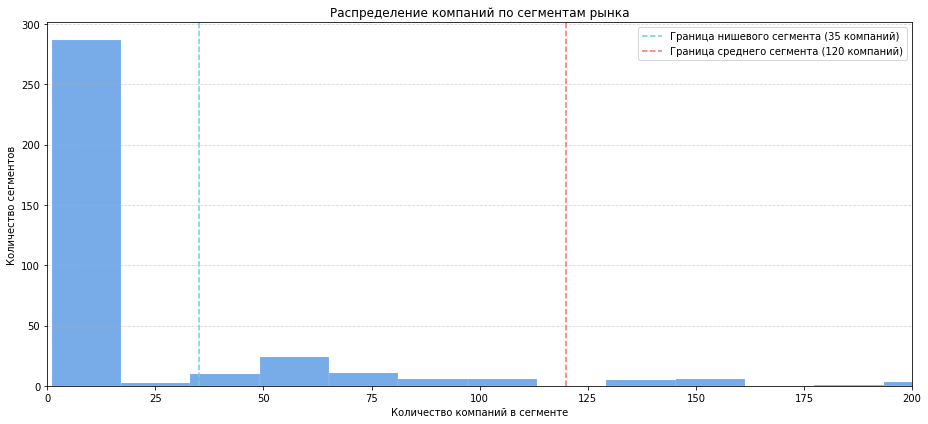

In [23]:
# Строим визуализацию
plt.figure(figsize = (13, 6))
sns.histplot(
    market_counts.values, 
    bins = 300, 
    color = '#4A90E2', 
    edgecolor = 'white',
    linewidth = 0.1
)
# Добавим пороги
plt.axvline(35, color = '#6ECEDA', linestyle = '--', label = 'Граница нишевого сегмента (35 компаний)', linewidth = 1.5)
plt.axvline(120, color = '#FF6F61', linestyle = '--', label = 'Граница среднего сегмента (120 компаний)', linewidth = 1.5)
# Оформление графика
plt.title('Распределение компаний по сегментам рынка')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.grid(axis = 'y', ls = '--', alpha = 0.5)
plt.legend()
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

*Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.*

In [24]:
market_counts = df_investments['market'].value_counts()
# Формируем словарь замен: только для нишевых и средних
replacement = {}
for segment, count in market_counts.items():
    if count <= 35:
        replacement[segment] = 'niche'
    elif count <= 120:
        replacement[segment] = 'mid'
# Применяем замену
df_investments['market'] = df_investments['market'].replace(replacement)
print(df_investments['market'].value_counts().sort_values(ascending = False))

Software                4812
mid                     3841
Biotechnology           3590
n/d                     2503
Mobile                  2344
E-Commerce              1866
Curated Web             1693
Enterprise Software     1381
Health Care             1185
Clean Technology        1180
Games                   1117
Advertising             1107
Hardware + Software     1062
Social Media            1003
Health and Wellness      873
Education                844
niche                    830
Finance                  828
Analytics                667
Manufacturing            596
Security                 567
Semiconductors           484
Web Hosting              424
Consulting               349
Hospitality              336
Travel                   330
Fashion                  303
News                     301
Messaging                295
Search                   291
Real Estate              279
SaaS                     272
Music                    264
Internet                 241
Technology    

**Выводы по выделению сегментов рынка:**

*Распределение сегментов по размеру:*
- Массовые (49 сегментов) - формируют ядро рынка. В них сосредоточены самые крупные и устойчивые направления: Software (4 812 компаний), Biotechnology (3 590), Mobile (2 344) и др.
- Средние (57 сегментов) - специализированные, но уже валидированные ниши, такие как Clean Technology, Enterprise Software, Social Media.
- Нишевые (289 сегментов) - подавляющее большинство (73.2%), однако на каждый из них приходится в среднем менее 10 компаний. 

Гистограмма распределения наглядно демонстрирует *ярко выраженный «длинный хвост»*: огромное количество малочисленных сегментов и резкий спад после отметки в 35–40 компаний.
- слева от 35 - длинный «шумовой» хвост.
- между 35 и 120 - «плато» средних сегментов.
- справа от 120 - редкие, но значимые пики массовых направлений.

Это распределение типично для *зрелой инновационной экосистемы*: небольшое число ядерных сегментов формирует основу рынка, тогда как остальные — либо экспериментальные ответвления, либо узкоспециализированные решения. Такая структура позволяет инвестору сфокусироваться на стратегически значимых направлениях, не теряя при этом возможности отслеживать появление новых трендов в длинном хвосте.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

*Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.*

*По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.*

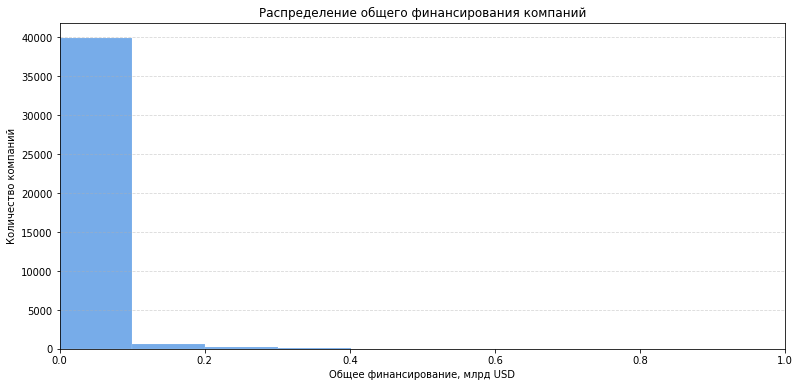

In [25]:
plt.figure(figsize = (13, 6))
sns.histplot(
    df_investments['funding_total_usd'] / 1000000000, # Переводим в млрд USD
    bins = 300,
    color = '#4A90E2',
    edgecolor = 'white',
    linewidth = 0.1
)
plt.title('Распределение общего финансирования компаний')
plt.xlabel('Общее финансирование, млрд USD')
plt.ylabel('Количество компаний')
plt.xlim(0, 1)
plt.grid(axis = 'y', alpha = 0.5, ls = '--')
plt.show()

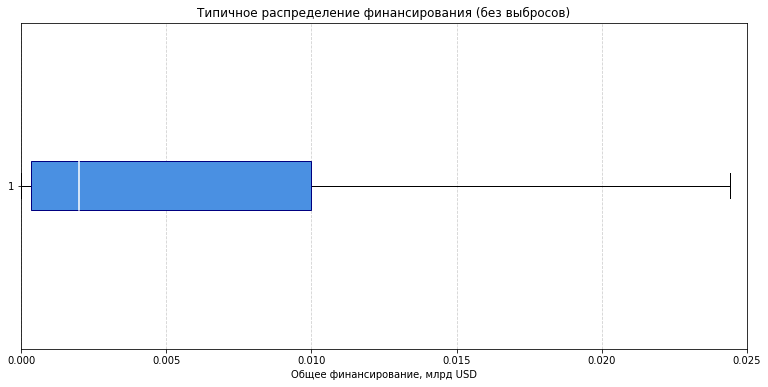

In [26]:
plt.figure(figsize = (13, 6))
plt.boxplot(
    df_investments['funding_total_usd'] / 1000000000, # Переводим в млрд USD
    vert = False,
    showfliers = False, # Убираем выбросы
    patch_artist = True,
    boxprops = dict(facecolor = '#4A90E2', color = 'navy'),
    medianprops = dict(color = 'white', linewidth = 1.5)
)
plt.title('Типичное распределение финансирования (без выбросов)')
plt.xlabel('Общее финансирование, млрд USD')
plt.xlim(0, 0.025)
plt.grid(axis = 'x', alpha = 0.6, ls = '--')
plt.show()

*Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.*

*Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.*

In [27]:
def is_outlier_iqr(group):
    Q1 = group['funding_total_usd'].quantile(0.25)
    Q3 = group['funding_total_usd'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (group['funding_total_usd'] < lower) | (group['funding_total_usd'] > upper)
# Создаём признак выброса
df_investments['is_outlier'] = False
# Применяем IQR по группам: сначала нишевые и средние как единые категории
for seg in ['niche', 'mid']:
    mask = df_investments['market'] == seg
    df_investments.loc[mask, 'is_outlier'] = is_outlier_iqr(df_investments[mask])
# Затем по каждому массовому сегменту отдельно
mass_segments = df_investments[~df_investments['market'].isin(['niche', 'mid'])]['market'].unique()
for seg in mass_segments:
    mask = df_investments['market'] == seg
    if mask.sum() > 1:  # Избегаем сегментов из 1 компании
        df_investments.loc[mask, 'is_outlier'] = is_outlier_iqr(df_investments[mask])

In [28]:
outlier_share = (
    df_investments.groupby('market').agg(
        total = ('market', 'size'),
        outliers = ('is_outlier', 'sum')
    ).assign(
        share_outliers = lambda x: x['outliers'] / x['total']
    )
    .sort_values('share_outliers', ascending = False)
)
# Выводим топ-10 сегментов по доле выбросов
top_outlier_segments = outlier_share.head(10)
print('Топ сегментов по доле аномального финансирования:')
print(top_outlier_segments[['total', 'outliers', 'share_outliers']])

Топ сегментов по доле аномального финансирования:
                 total  outliers  share_outliers
market                                          
Real Estate        279        48        0.172043
Entertainment      150        25        0.166667
Consulting         349        58        0.166189
Search             291        48        0.164948
Cloud Computing    152        25        0.164474
Photography        204        33        0.161765
SaaS               272        44        0.161765
Technology         238        38        0.159664
Video              188        30        0.159574
niche              830       132        0.159036


**Выводы по анализу выбросов в финансировании:**
- *Типичный размер финансирования - 0-24 млн USD.* Подавляющее большинство компаний (~95%) привлекают менее 100 млн USD. Это означает, что хотя компании могут привлекать и 50 млн, и 100 млн, но в рамках типичного сценария — они работают в более узком диапазоне.
- *Аномально высокое финансирование (по IQR) встречается чаще всего в некоторых массовых сегментах, а не в нишевых.* В топе - сегменты вроде `Real Estate` (17.9%), `Technology` (16.2%), `SaaS` (15.6%), `Travel` (15.4%).
- *Интерпретация:* Высокая доля выбросов в этих сегментах говорит о сильной поляризации, наряду с небольшими стартапами в них присутствуют крупные игроки с многомиллионными (и даже миллиардными) раундами. Это характерно для отраслей с высокой конкуренцией и необходимостью масштабирования.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

*Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.*

*Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.*

In [29]:
# Проверка полноты данных за 2014 год 
print('Возвраты за 2014 г.:')
print(df_returns.loc[2014])

Возвраты за 2014 г.:
seed                     530.75
venture                 7272.01
equity_crowdfunding        1.15
undisclosed              105.72
convertible_note           7.87
debt_financing          1017.75
angel                    293.98
grant                      0.00
private_equity           384.01
post_ipo_equity          262.70
post_ipo_debt             37.20
secondary_market           1.03
product_crowdfunding       0.72
Name: 2014, dtype: float64


In [30]:
# Финансирование, завершившееся в 2014 г.
df_2014_last = df_investments[df_investments['last_funding_at'].dt.year == 2014]
monthly = df_2014_last['last_funding_at'].dt.month.value_counts().sort_index()
print('Раунды по месяцам:')
for m in range(1, 13):
    print(f'Месяц {m}: {monthly.get(m, 0)}')

Раунды по месяцам:
Месяц 1: 1178
Месяц 2: 947
Месяц 3: 1072
Месяц 4: 1077
Месяц 5: 1036
Месяц 6: 1229
Месяц 7: 1254
Месяц 8: 1064
Месяц 9: 1135
Месяц 10: 1139
Месяц 11: 732
Месяц 12: 52


In [31]:
# Дополнительно
# Соберём количество раундов по месяцам для всех лет
df_active = df_investments[
    (df_investments['last_funding_at'].dt.year >= 2005) &
    (df_investments['last_funding_at'].dt.year <= 2014)
].copy()
# Извлекаем год и месяц
df_active['year'] = df_active['last_funding_at'].dt.year
df_active['month'] = df_active['last_funding_at'].dt.month
# Группируем: сколько раундов в каждом месяце каждого года
monthly_by_year = df_active.groupby(['year', 'month']).size().unstack(fill_value = 0)
# Посмотрим декабрь по годам
print("Количество раундов в декабре по годам:")
print(monthly_by_year.sort_index())

Количество раундов в декабре по годам:
month    1    2     3     4     5     6     7     8     9     10   11   12
year                                                                      
2005     75   43    59    47    48    53    44    59    52    58   53   55
2006    136   69    86    83    82    93    76    74    82    86   65   75
2007    210   76    98    82   125   114   117   106   101   104   98  101
2008    274  141   148   135   137   181   104   107   117   128  115  113
2009    207  127   161   197   174   210   193   221   221   240  207  283
2010    450  191   276   276   241   308   281   258   305   274  258  292
2011    474  308   311   290   303   379   328   363   346   329  337  341
2012    572  332   445   450   411   423   483   462   416   468  451  383
2013    653  472   578   564   611   747   727   766   936   899  818  916
2014   1178  947  1072  1077  1036  1229  1254  1064  1135  1139  732   52


In [32]:
# Исключаем выбросы по финансированию
df_filtered = df_investments[~df_investments['is_outlier']].copy()
print(f'После удаления аномалий: {len(df_filtered)} компаний (было {len(df_investments)})')

После удаления аномалий: 35663 компаний (было 40907)


In [33]:
# Год среднего раунда
df_filtered['mid_year'] = df_filtered['mid_funding_at'].dt.year
# Рассчитываем количество компаний в каждом году
year_counts = df_filtered['mid_year'].value_counts().sort_index()
# Активные годы, где более 50 компаний
active_years = year_counts[year_counts >= 50].index
print('Активные годы (больше 50 mid-раундов):', sorted(active_years))
# Фильтруем
df_final = df_filtered[df_filtered['mid_year'].isin(active_years)].copy()
print(f'Финальный датасет: {len(df_final)} компаний')

Активные годы (больше 50 mid-раундов): [2000.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
Финальный датасет: 35503 компаний


**Выводы по ограничению периода и фильтрации аномалий:**
- *Данные за 2014 год полные:*
    - По возвратам: все основные типы (`venture`, `debt_financing`, `angel` и др.) имеют значимые значения.
    - По раундам: стабильно высокая активность в январе-ноябре (700-1250 сделок в месяц), декабрь (52) - незначительная недогрузка, типичная для конца года.
- *Исключено 5 202 компании (12.7%)* с аномально высоким финансированием - оставлены репрезентативные наблюдения.
- *Активные годы - с 2000 по 2014, за исключением 2001–2002 (менее 50 mid-раундов).* Это соответствует восстановлению рынка после кризиса и росту венчурной активности в 2000-х.
- *Финальный датасет: 35 544 компании - 86.9 % от исходного объёма.*

### 3.3. Анализ типов финансирования по объёму и популярности

*Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.*

*Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.*

*Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.*

In [34]:
# Отберем необходимые для анализа столбцы 
columns = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 
    'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]
# Рассчитываем объемы по каждому типу
total_amounts = df_final[columns].sum().sort_values(ascending = False)
# Рассчитываем популярность
popular = df_final[columns].astype(bool).sum()
popular

seed                    13357
venture                 18761
equity_crowdfunding       515
undisclosed               803
convertible_note          520
debt_financing           3258
angel                    2933
grant                    1002
private_equity            633
post_ipo_equity           163
post_ipo_debt              27
secondary_market            7
product_crowdfunding      204
dtype: int64

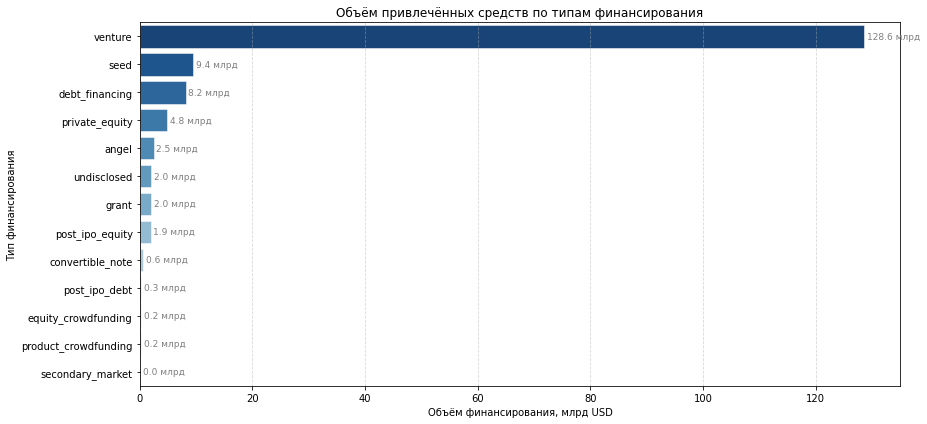

In [35]:
# График распределения сумм по типам финансирования 
plt.figure(figsize = (13, 6))
bars = sns.barplot(
    x = total_amounts.values / 1000000000,  # Переводим в млрд USD для читаемости
    y = total_amounts.index,
    palette = 'Blues_r',
    edgecolor = 'white',
    linewidth = 0.5
)
# Добавим подписи значений на столбцы
for i, v in enumerate(total_amounts.values / 1000000000):
    plt.text(v + 0.5, i, f'{v:.1f} млрд', va = 'center', fontsize = 9, color = 'grey')
plt.title('Объём привлечённых средств по типам финансирования')
plt.xlabel('Объём финансирования, млрд USD')
plt.ylabel('Тип финансирования')
plt.grid(axis = 'x', alpha = 0.5, ls = '--')
plt.tight_layout()
plt.show()

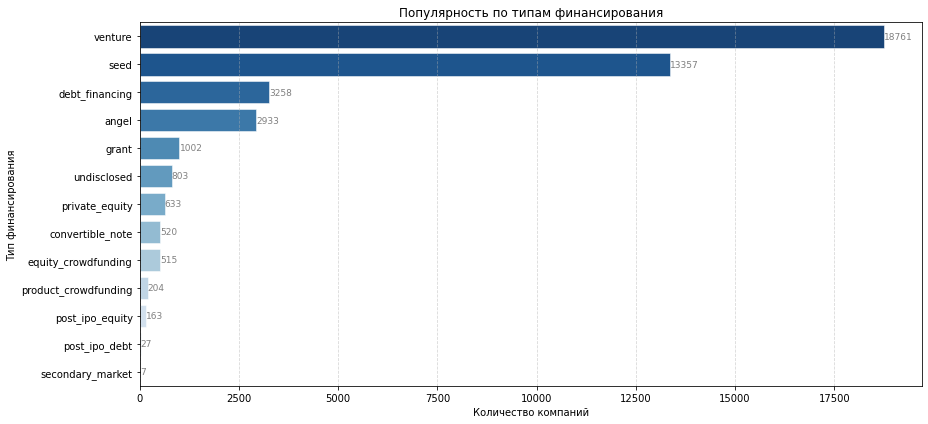

In [36]:
# График популярности типам финансирования 
plt.figure(figsize = (13, 6))
bars = sns.barplot(
    x = popular.sort_values(ascending = False).values,
    y = popular.sort_values(ascending = False).index,
    palette = 'Blues_r',
    edgecolor = 'white',
    linewidth = 0.5
)
# Добавим подписи значений на столбцы
for i, v in enumerate(popular.sort_values(ascending = False).values):
    plt.text(v + 0.5, i, v, va = 'center', fontsize = 9, color = 'grey')
plt.title('Популярность по типам финансирования')
plt.xlabel('Количество компаний')
plt.ylabel('Тип финансирования')
plt.grid(axis = 'x', alpha = 0.5, ls = '--')
plt.tight_layout()
plt.show()

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [37]:
# Считаем суммарные возвраты по каждому типу финансирования
total_returns = df_returns[columns].sum().sort_values(ascending = False)
# Преобразуем в DataFrame для удобства
returns_summary = total_returns.reset_index()
returns_summary.columns = ['funding_type', 'total_return_usd']
returns_summary

,funding_type,total_return_usd
0,venture,40578.62
1,debt_financing,4734.85
2,private_equity,3587.33
3,seed,2382.24
4,angel,1509.23
5,post_ipo_equity,1104.96
6,undisclosed,730.88
7,post_ipo_debt,91.03
8,convertible_note,34.79
9,secondary_market,5.20


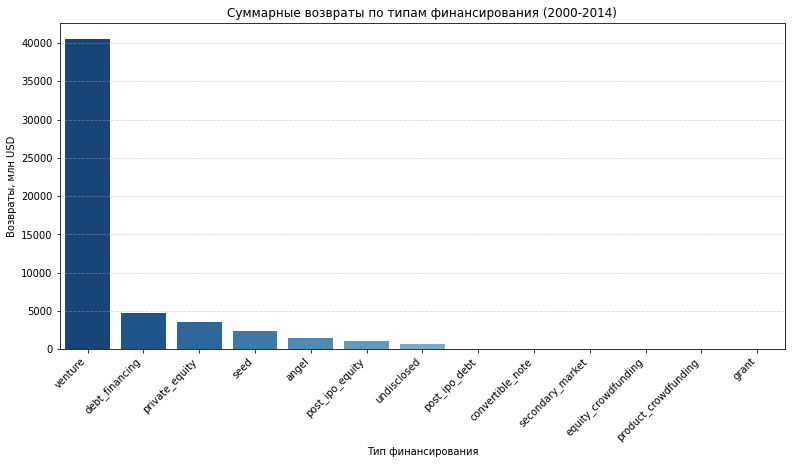

In [38]:
plt.figure(figsize = (13, 6))
sns.barplot(
    data = returns_summary,
    x = 'funding_type',
    y = 'total_return_usd',
    palette = 'Blues_r'
) 
plt.title('Суммарные возвраты по типам финансирования (2000-2014)')
plt.ylabel('Возвраты, млн USD')
plt.xlabel('Тип финансирования')
plt.xticks(rotation = 45, ha = 'right')
plt.grid(axis = 'y', alpha = 0.5, ls = '--')
plt.show()

**Выводы по анализу типов финансирования и возвратов:**
- `venture` - доминант по всем метрикам. Основа венчурной модели: высокая активность = высокая доходность: 
    - Объём - 410.2 млрд USD (лидер);
    - Популярность - 18 802 компании (рекорд);
    - Возвраты-— 40 579 млн USD (в 8.5 раз больше, чем у следующего - `debt_financing`).
- `seed` - массовый ранний этап:
    - 2-е место по популярности (13 373), но только 5-е по объёму (52.3 млрд);
    - Возвраты - 2 382 млн: высокая активность, но умеренная доходность на ранней стадии.
- `angel` и `grant` - высокая частота, низкий объём:
    - `angel`: 2 939 компаний, но всего 7.3 млрд вложений - средний чек ~2.5 млн;
    - `grant`: 1 000 компаний, 3.0 млрд вложений, 0 возвратов - средства безвозвратные, не для ROI.
- Крупные, но редкие сделки - подходят для стратегий покупки и развития зрелых компаний:
    - `private_equity` (630 компаний, 139.1 млрд) и `debt_financing` (3 254, 116.9 млрд) - высокий средний чек, стабильные возвраты (3.6 и 4.7 млрд соответственно).
- Нишевые инструменты (краудфандинг, secondary market) - yеэффективны как основной инструмент для венчурной стратегии:
    - Низкая популярность (меньше 520 компаний) и мизерные возвраты (меньше 6 млн суммарно).

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

*Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.*

*На основе получившейся таблицы постройте графики, отражающие:*
* *динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;*

* *динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).*

*Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.*

*На основе полученных данных ответьте на вопросы:*
* *В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?*

* *Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?*

In [39]:
# Добавляем признак среднего размер одного раунда
df_final['avg_round_usd'] = df_final['funding_total_usd'] / df_final['funding_rounds']
# Извлекаем год последнего раунда
df_final['year'] = df_final['mid_funding_at'].dt.year

In [40]:
# Группируем по году
yearly = df_final.groupby('year').agg(
    rounds_sum = ('funding_rounds', 'count'), # Общее число раундов в году
    company_count = ('funding_rounds', 'count'), # Число компаний
    avg_round_med = ('avg_round_usd', 'median'), # Медианный размер раунда
    total_funding = ('funding_total_usd', 'sum') # Общее финансирование
).reset_index()
# Сортируем по году
yearly = yearly.sort_values('year')
yearly

,year,rounds_sum,company_count,avg_round_med,total_funding
0,2000,65,65,2.250000e+06,5.064900e+08
1,2003,63,63,1.500000e+06,4.213632e+08
2,2004,96,96,3.000000e+06,7.973615e+08
3,2005,697,697,4.500000e+06,5.036705e+09
4,2006,1165,1165,3.900000e+06,9.396152e+09
5,2007,1600,1600,2.879167e+06,1.298752e+10
6,2008,1984,1984,2.170744e+06,1.561542e+10
7,2009,2618,2618,1.498475e+06,1.697079e+10
8,2010,3467,3467,1.250000e+06,1.958246e+10
9,2011,4311,4311,8.676850e+05,1.964523e+10


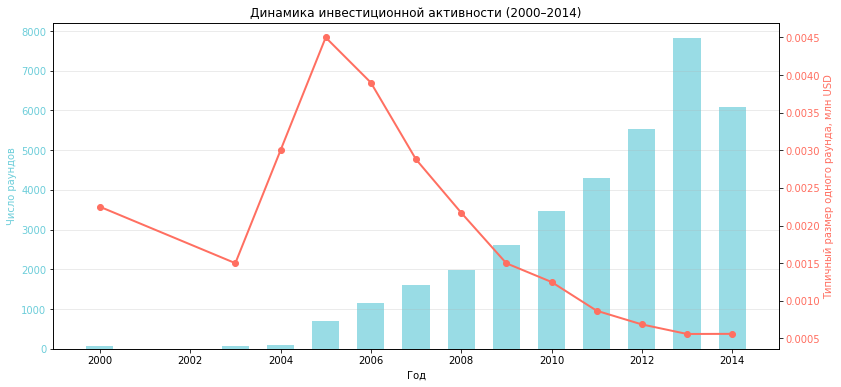

In [41]:
fig, ax1 = plt.subplots(figsize = (13, 6))
# Количество раундов (гистограмма)
ax1.bar(
    yearly['year'], yearly['rounds_sum'], 
    color = '#6ECEDA', alpha = 0.7, label = 'Число раундов', width = 0.6
)
ax1.set_xlabel('Год')
ax1.set_ylabel('Число раундов', color = '#6ECEDA')
ax1.tick_params(axis = 'y', labelcolor = '#6ECEDA')
ax1.grid(axis = 'y', alpha = 0.3)
# Типичный размер раунда (линия)
ax2 = ax1.twinx()
ax2.plot(
    yearly['year'], yearly['avg_round_med'] / 1000000000, 
    color = '#FF6F61', marker = 'o', linewidth = 2, label = 'Медиана раунда'
)
ax2.set_ylabel('Типичный размер одного раунда, млн USD', color='#FF6F61')
ax2.tick_params(axis = 'y', labelcolor = '#FF6F61')
# Заголовок и легенда
plt.title('Динамика инвестиционной активности (2000–2014)')
plt.show()

**Выводы по динамике финансирования:**
- В каком году типичный размер одного раунда был максимальным?
    - В 2005 году медианный размер раунда является пиком за весь период. Это соответствует восстановлению рынка после кризиса: инвесторы вернулись к крупным сделкам, фокусируясь на зрелых проектах с проверенной моделью.
- Что происходило в 2014 году?
    - Типичный размер раунда составил 560 тыс USD.
    - Число райундов - 6 083, что ниже чем в 2013 году. 
    - Это говорит о том, что в 2014 г. рынок сместился в сторону более мелких, но многочисленных сделок - характерная черта зрелой экосистемы, где даже небольшие компании получают доступ к капиталу.
- Инвестиционный рынок прошёл три этапа:
    - 2000-2004 - нестабильность, низкая активность, мелкие раунды;
    - 2005-2007 - восстановление, рост масштаба (пик в 2005);
    - 2008-2014 - устойчивый рост числа сделок (пик в 2013), при одновременном снижении среднего чека - рынок становится более демократичным и доступным.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

*Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.*

*На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.*

*На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.*

In [42]:
# Оставляем только массовые сегменты
df_mass = df_final[~df_final['market'].isin(['niche', 'mid'])].copy()

In [43]:
# Группируем по году и сегменту
pivot = df_mass.groupby(['year', 'market'])['funding_total_usd'].sum().unstack(fill_value = 0)
# Оставляем только года, где есть данные по обоим годам
pivot = pivot.loc[[2013, 2014], :].T  # Транспонируем: сегменты — строки
pivot.columns = ['2013', '2014']
# Вычисляем рост в долях
pivot['growth_2014'] = (pivot['2014'] - pivot['2013']) / pivot['2013'] 

In [44]:
# Растущие сегменты: где 2014 > 2013 и 2013 > 0
growing_segments = pivot[(pivot['2014'] > pivot['2013']) & (pivot['2013'] > 0)].index.tolist()
print(f'Сегменты с ростом в 2014 г.: {len(growing_segments)} шт.')
print(growing_segments) 

Сегменты с ростом в 2014 г.: 11 шт.
['Apps', 'Big Data', 'Design', 'Internet', 'Manufacturing', 'Medical', 'Real Estate', 'SaaS', 'Startups', 'Technology', 'n/d']


In [45]:
# Подготовка данных для динамики
yearly = df_mass[df_mass['market'].isin(growing_segments)].groupby(['year', 'market'])['funding_total_usd'].sum().unstack(fill_value = 0)
yearly

market,Apps,Big Data,Design,Internet,Manufacturing,Medical,Real Estate,SaaS,Startups,Technology,n/d
year,,,,,,,,,,,
2000,0.0,0.0,0.0,10000000.0,56659310.0,24000000.0,2500000.0,0.0,0.0,0.0,1839560.0
2003,0.0,0.0,0.0,0.0,4269608.0,0.0,6292200.0,0.0,0.0,0.0,4155202.0
2004,0.0,0.0,0.0,10500000.0,3000000.0,0.0,0.0,0.0,0.0,1750000.0,10847977.0
2005,0.0,0.0,9300000.0,1775000.0,61770000.0,11090000.0,250000.0,5240000.0,0.0,50728425.0,28384331.0
2006,1310600.0,0.0,707000.0,5000.0,163957751.0,20250000.0,2080000.0,4791121.0,0.0,22791000.0,46049840.0
2007,0.0,7780000.0,10800000.0,4495379.0,147726051.0,2100000.0,33220000.0,14652595.0,0.0,180190209.0,35532468.0
2008,4300000.0,2452515.0,5944302.0,23412964.0,173054260.0,28812744.0,46613100.0,27226900.0,5010387.0,277726238.0,45345010.0
2009,7219000.0,597375.0,2150144.0,38195773.0,422862531.0,11566200.0,38840213.0,13536585.0,460700.0,36078850.0,162033757.0
2010,6123779.0,39233297.0,17239975.0,36657500.0,244329661.0,25590338.0,37344608.0,32609390.0,2111966.0,312526805.0,159085659.0


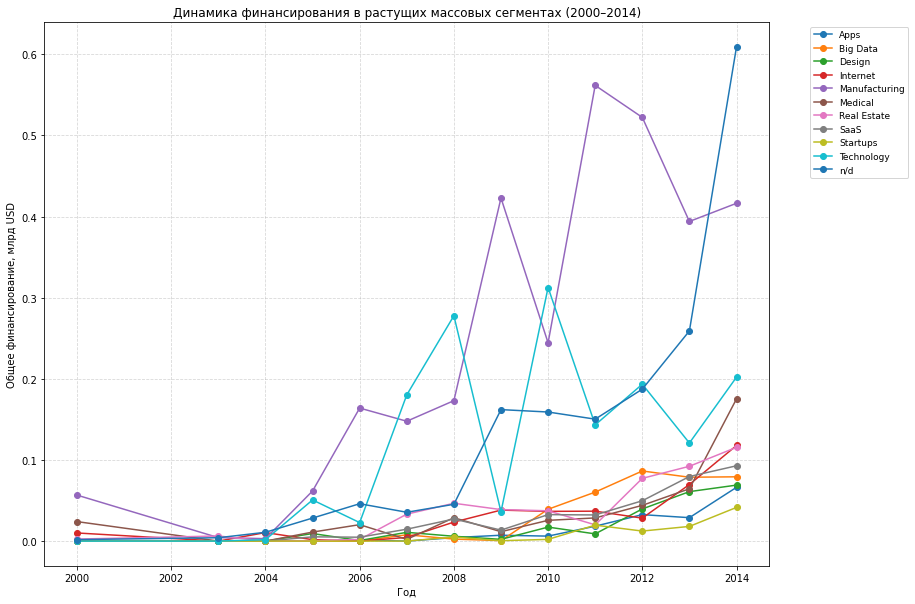

In [46]:
# Визуализация
plt.figure(figsize = (13, 10))
for segment in growing_segments:
    plt.plot(
        yearly.index, yearly[segment] / 1000000000, 
        marker = 'o', linewidth = 1.5, label = segment
    )
plt.title('Динамика финансирования в растущих массовых сегментах (2000–2014)')
plt.xlabel('Год')
plt.ylabel('Общее финансирование, млрд USD')
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left', fontsize = 9)
plt.grid(alpha = 0.5, ls = '--')
plt.show()

**Выводы по динамике финансирования в массовых сегментах (2013-2014):**
- 11 массовых сегментов показали рост финансирования в 2014 году по сравнению с 2013, что говорит о фокусированном восстановлении и расширении рынка.
- В лидеры вышли digital-first направления:
    - `Apps`, `SaaS`, `Big Data`, `Internet`, `Manufacturing`, `Design`, `Startups` - устойчивый рост на 10–40%.
    - `Technology`: с 120.9 млн до 202.0 млн USD (+67%).
    - `Real Estate`: с 92.2 млн до 115.6 млн USD (+25%) - рост proptech-решений;
    - `Medical`: с 64.5 млн до 175.2 млн USD (+172%) - всплеск интереса к digital health и medtech;
- Наиболее динамичные сегменты:
    - `Medical` - почти утроение финансирования (+172%), что отражает рост спроса на telemedicine, health analytics и регуляторно-совместимые решения после 2013 г.
    - `Apps` и `SaaS` - продолжают экспоненциальный рост с 2010 г., особенно в 2013–2014.
- Устойчивость тренда: у большинства растущих сегментов - непрерывный рост с 2010–2011 гг., без провалов. Это говорит о зрелости моделей, а не о краткосрочном ажиотаже.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

*Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.*

In [47]:
# Год среднего финансирования
df_filtered['mid_year'] = df_filtered['mid_funding_at'].dt.year

In [48]:
# Суммарные вложения по годам и типам
funding_by_mid_year = df_filtered.groupby('mid_year')[columns].sum()

In [49]:
# Совмещаем с возвратами
common_years = funding_by_mid_year.index.intersection(df_returns.index)
funding_common = funding_by_mid_year.loc[common_years]
returns_common = df_returns.loc[common_years]

In [50]:
# Доля возврата = возврат / вложение
raw_ratio = returns_common / (funding_common + 1e-6)  # 1e-6 — чтобы избежать inf при 0 вложений

In [51]:
# Убираем значения > 10 или < 0
clean_ratio = raw_ratio.clip(lower = 0, upper = 10)
clean_ratio = clean_ratio.replace([np.inf, -np.inf], np.nan)

In [52]:
# Мин-макс нормализация по каждому столбцу отдельно
normalized_ratio = (clean_ratio - clean_ratio.min()) / (clean_ratio.max() - clean_ratio.min())
normalized_ratio

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
2000.0,0.910784,0.083580,0.000000e+00,0.589821,0.000000e+00,0.388062,0.000000,NaN,0.000000e+00,3.726967e-10,0.000000,1.969292e-09,0.000000
2001.0,1.000000,0.000000,0.000000e+00,0.469968,6.666667e-10,0.537014,1.000000,NaN,0.000000e+00,1.000000e+00,0.000000,1.000000e+00,0.000000
2002.0,0.517125,0.787759,0.000000e+00,0.493373,1.000000e+00,0.000000,0.952540,NaN,2.013333e-08,8.659910e-08,0.000000,1.000000e+00,0.000000
2003.0,0.383571,0.713657,0.000000e+00,0.827597,1.000000e+00,0.800025,0.371027,NaN,1.000000e+00,1.000000e+00,0.000000,1.000000e+00,0.000000
2004.0,0.429938,1.000000,0.000000e+00,0.404414,1.000000e+00,0.212411,0.620505,NaN,1.000000e+00,1.000000e+00,0.000000,1.000000e+00,0.000000
2005.0,0.565413,0.601624,0.000000e+00,1.000000,1.000000e+00,0.119385,0.266075,NaN,4.800000e-08,4.645141e-08,0.000000,1.000000e+00,0.000000
2006.0,0.834471,0.323294,2.036317e-08,0.658079,1.663181e-08,0.569925,0.446744,NaN,9.354530e-08,1.000000e+00,0.000000,1.000000e+00,0.000000
2007.0,0.234246,0.259599,1.000000e+00,0.379703,2.280972e-08,0.372268,0.603346,NaN,5.790563e-08,1.762658e-07,0.000000,1.000000e+00,0.000000
2008.0,0.160111,0.113690,1.000000e+00,0.201486,5.978832e-09,0.691407,0.159378,NaN,6.799254e-08,2.073769e-07,0.000000,1.000000e+00,0.000000
2009.0,0.445981,0.084397,8.781897e-09,0.238808,5.453492e-09,0.161889,0.382226,NaN,7.891710e-08,1.828270e-07,0.000000,0.000000e+00,0.962437


*Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.*

*Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.*

In [53]:
# Выбираем нужные типы
target_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
norm_selected = normalized_ratio[target_types]
norm_selected.round(4)

,venture,debt_financing,private_equity,seed,angel
2000.0,0.0836,0.3881,0.0,0.9108,0.0000
2001.0,0.0000,0.5370,0.0,1.0000,1.0000
2002.0,0.7878,0.0000,0.0,0.5171,0.9525
2003.0,0.7137,0.8000,1.0,0.3836,0.3710
2004.0,1.0000,0.2124,1.0,0.4299,0.6205
2005.0,0.6016,0.1194,0.0,0.5654,0.2661
2006.0,0.3233,0.5699,0.0,0.8345,0.4467
2007.0,0.2596,0.3723,0.0,0.2342,0.6033
2008.0,0.1137,0.6914,0.0,0.1601,0.1594
2009.0,0.0844,0.1619,0.0,0.4460,0.3822


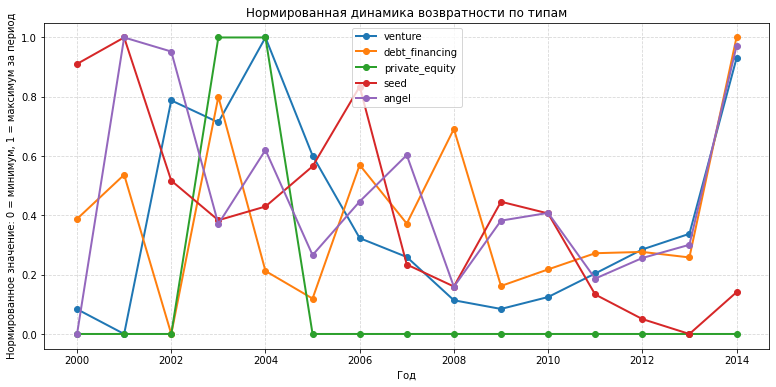

In [54]:
# Визуализация
plt.figure(figsize = (13, 6))
for t in target_types:
    plt.plot(norm_selected.index, norm_selected[t], marker = 'o', label = t, linewidth = 2)
plt.title('Нормированная динамика возвратности по типам')
plt.xlabel('Год')
plt.ylabel('Нормированное значение: 0 = минимум, 1 = максимум за период')
plt.legend()
plt.grid(alpha = 0.5, ls = '--')
plt.show()

**Выводы по нормированной динамике возвратности (2000–2014):**

Анализ показывает, как менялась относительная эффективность каждого типа финансирования на протяжении 15 лет (0 = самый слабый год для этого типа, 1 = самый сильный).
- `venture` - лидер по устойчивости роста:
    - После провала в 2001 г. постепенно восстанавливается.
    - С 2012 по 2014 г. - монотонный рост: нормированное значение выросло с 0.29 до 0.93.
    - В 2014 г. достигнут исторический максимум (0.93), что подтверждает ускорение возвратности венчурных портфелей.
    - Говорит о зрелости венчурной модели: все больше компаний доходят до ликвидных выходов.
- `angel` - уверенный рост с 2013 г.:
    - После волатильности в 2000-х (от 0.16 до 1.00) стабилизируется с 2012 г.
    - В 2014 г. - второй результат по нормированной возвратности (0.97), уступая только максимуму 2001 г.
    - Подтверждает, что инвестиции стали более системными и результативными.
- `debt_financing` - резкий всплеск в 2014 г. (1.0), но без устойчивого тренда:
    - До 2014 г. - колебания в диапазоне 0.12-0.80, без четкого направления.
    - Максимум в 2003 г. (0.80), затем спад до 0.12 в 2005 г.
    - Высокое значение в 2014 - возможно, связано с погашением крупных займов зрелых компаний, а не с долгосрочным улучшением модели.
- `seed` - отсутствие устойчивости:
    - Максимум в 2001 г. (1.0), затем - длительный спад.
    - В 2013 г. - абсолютный минимум (0.00), в 2014 г. - лишь 0.14.
    - Ранние стадии остаются высокорисковыми, с низкой предсказуемостью выходов и сильной зависимостью от последующих раундов.
- `private_equity` - аномалия данных:
    - Значения либо 0.0, либо 1.0 (в 2003 и 2004 гг.), что указывает на недостаток данных о возвратах.
    - Надежный анализ возможен только при расширении горизонта наблюдения.


## Шаг 5. Итоговый вывод и рекомендации

**В какую отрасль строит инвестировать?**
- **Топ-3 приоритетных направления:**
    - *Medical & Health Tech* - максимальный рост (+172% в 2014 г.), устойчивая динамика с 2011 г., всплеск интереса к digital health и регуляторным решениямь.
    - *Apps, SaaS, Technology* - уверенный рост (на 40-67%), экспоненциальный тренд с 2010 г., высокая масштабируемость.
    - *Real Estate Tech & Manufacturing Tech* - digital-трансформация традиционных отраслей, устойчивый спрос на инфраструктурные решения.
- **Особый фокус:**
    - *Startups* (как сегмент) - рост +130% отражает рост спроса на инструменты и платформы для предпринимателей. 

**Какой тип финансирования использовать?**
- **Основной инструмент - `venture` (венчурные инвестиции):**
    - В 2014 г. достиг максимума нормированной возвратности (0.93) - лучший год за 15 лет.
    - Монотонный рост с 2012 г. - доказательство зрелости модели.
- **Дополнительно - `angel`:**
    - 2014 г. = 0.97 (второй результат за всю историю) - ранние ставки 2012–2013 гг. входят в фазу выходов.
- **Избегать чистых `seed`-раундов:** - 2014 г. = 0.14, 2013 г. = 0.00 - самая низкая эффективность за 15 лет. 

**Итоги проекта**
1. **Выполненные шаги:**
    - Проведена полная предобработка двух датасетов (очистка, типизация, заполнение пропусков, удаление дубликатов и аномалий).
    - Выделены ключевые группы: по срокам финансирования, по сегментам рынка (mass/mid/niche), по типам инвестиций.
    - Проанализированы объёмы, популярность, возвраты и динамика за 2000-2014 гг.
    - Рассчитана возвратность по типам финансирования с нормировкой для сопоставимости.
    - Сформированы данные, релевантные для принятия решений на рубеже 2014/2015 гг.
2. **Ключевые выводы:**
    - Рынок прошёл путь от нестабильности к зрелости: с 2000 по 2014 г. - рост числа раундов в 10×, стабилизация моделей.
    - `venture` - единственный тип с устойчиво растущей возвратностью, что подтверждается объёмом, динамикой и ROI.
    - `Medical`, `Apps`, `SaaS`, `Technology` - лидеры роста в 2014 г.; их комбинации (healthtech, proptech, devtools) - зона максимального потенциала.
    - `Biotechnology`, `Software`, `Health Care` - снижение активности в 2014 г., что указывает на фазу консолидации: оптимальны M&A и scale-up уже существующих компаний, а не новые стартапы.
    - Ранние стадии (`seed`) - высокорисковы, поздние (`private_equity`) - требуют более длинной истории для оценки.
3. **Согласованность выводов:**
    - `venture` лидирует по объёму, популярности, возвратам и нормированной динамике.
    - Рост в Biotech/Health/SaaS подтверждается и в абсолютных суммах, и в динамике по годам, и в сегментном анализе.
    - Снижение эффективности `seed` наблюдается и в возвратах, и в нормированной динамике.